<a href="https://colab.research.google.com/github/MClem72026/HF-Analytics-Course/blob/main/PythonProject1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv"
df = pd.read_csv(url)
print(df.head())

  School DBN                     School Name School Level  \
0     01M034  P.S. 034 Franklin D. Roosevelt          K-8   
1     01M034  P.S. 034 Franklin D. Roosevelt          K-8   
2     01M034  P.S. 034 Franklin D. Roosevelt          K-8   
3     01M140          P.S. 140 Nathan Straus          K-8   
4     01M140          P.S. 140 Nathan Straus          K-8   

          Regents Exam  Year  Total Tested Mean Score Number Scoring Below 65  \
0  Common Core Algebra  2017             4          s                       s   
1   Living Environment  2015            16       77.9                       1   
2   Living Environment  2016             9         74                       1   
3  Common Core Algebra  2016             3          s                       s   
4  Common Core Algebra  2017             2          s                       s   

  Percent Scoring Below 65 Number Scoring 65 or Above  \
0                        s                          s   
1                      6.3      

In [3]:
print(df.columns )
print(df.info())

Index(['School DBN', 'School Name', 'School Level', 'Regents Exam', 'Year',
       'Total Tested', 'Mean Score', 'Number Scoring Below 65',
       'Percent Scoring Below 65', 'Number Scoring 65 or Above',
       'Percent Scoring 65 or Above', 'Number Scoring 80 or Above',
       'Percent Scoring 80 or Above', 'Number Scoring CR',
       'Percent Scoring CR'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212331 entries, 0 to 212330
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   School DBN                   212331 non-null  object
 1   School Name                  212331 non-null  object
 2   School Level                 212331 non-null  object
 3   Regents Exam                 212321 non-null  object
 4   Year                         212331 non-null  int64 
 5   Total Tested                 212331 non-null  int64 
 6   Mean Score                   212331 

In [10]:
df.replace(['s', 'NA'], pd.NA, inplace=True)
df['Mean Score'] = pd.to_numeric(df['Mean Score'], errors='coerce')
df_clean = df.dropna(subset=['Mean Score'])
print(df_clean.head())

  School DBN                     School Name School Level        Regents Exam  \
1     01M034  P.S. 034 Franklin D. Roosevelt          K-8  Living Environment   
2     01M034  P.S. 034 Franklin D. Roosevelt          K-8  Living Environment   
5     01M140          P.S. 140 Nathan Straus          K-8  Living Environment   
6     01M140          P.S. 140 Nathan Straus          K-8  Living Environment   
7     01M140          P.S. 140 Nathan Straus          K-8  Living Environment   

   Year  Total Tested  Mean Score Number Scoring Below 65  \
1  2015            16        77.9                       1   
2  2016             9        74.0                       1   
5  2015             9        67.4                       3   
6  2016            15        72.6                       2   
7  2017             9        64.4                       5   

  Percent Scoring Below 65 Number Scoring 65 or Above  \
1                      6.3                         15   
2                     11.1      

In [59]:
school_name = "Brooklyn Ascend Charter School"
school_df = df_clean[df_clean['School Name'].str.upper() == school_name.upper()]
print(school_df.head())

      School DBN                     School Name     School Level  \
17982     84K652  Brooklyn Ascend Charter School  K-12 all grades   
17983     84K652  Brooklyn Ascend Charter School  K-12 all grades   
17986     84K652  Brooklyn Ascend Charter School  K-12 all grades   
17987     84K652  Brooklyn Ascend Charter School  K-12 all grades   
17988     84K652  Brooklyn Ascend Charter School  K-12 all grades   

                       Regents Exam  Year  Total Tested  Mean Score  \
17982           Common Core Algebra  2016            66        72.2   
17983           Common Core Algebra  2017            87        70.8   
17986           Common Core English  2017            21        81.0   
17987          Common Core Geometry  2017            55        54.5   
17988  Global History and Geography  2017            59        70.1   

      Number Scoring Below 65 Percent Scoring Below 65  \
17982                      11                     16.7   
17983                      18             

In [58]:
school_mean = school_df['Mean Score'].mean()
print("School Mean Score:", school_mean)

School Mean Score: 68.15


In [57]:
print("Unique borough values in dataset:", df_clean['Borough'].unique())
borough_df = df_clean[df_clean['Borough'] == 'Brooklyn']
print("Rows in Brooklyn dataset:", len(borough_df))

borough_mean = borough_df['Mean Score'].mean()
print("School Mean:", school_mean)
print("Brooklyn Average:", borough_mean)

Unique borough values in dataset: ['Manhattan' 'Bronx' 'Brooklyn' 'Queens' 'Staten Island']
Rows in Brooklyn dataset: 38694
School Mean: 68.15
Brooklyn Average: 64.8210394376389


In [36]:
print("Overall Descriptive Statistics for Mean Score:")
print(df_clean['Mean Score'].describe())

Overall Descriptive Statistics for Mean Score:
count    137109.000000
mean         65.998967
std          11.288883
min          15.000000
25%          58.300000
50%          65.400000
75%          73.400000
max          98.700000
Name: Mean Score, dtype: float64


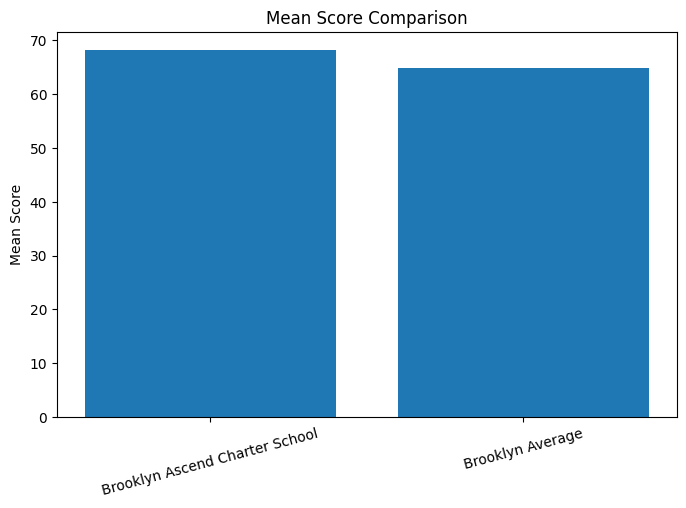

In [61]:
labels = ['Brooklyn Ascend Charter School', 'Brooklyn Average']
values = [school_mean, borough_mean]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.title('Mean Score Comparison')

plt.ylabel('Mean Score')
plt.xticks(rotation=15)
plt.show()


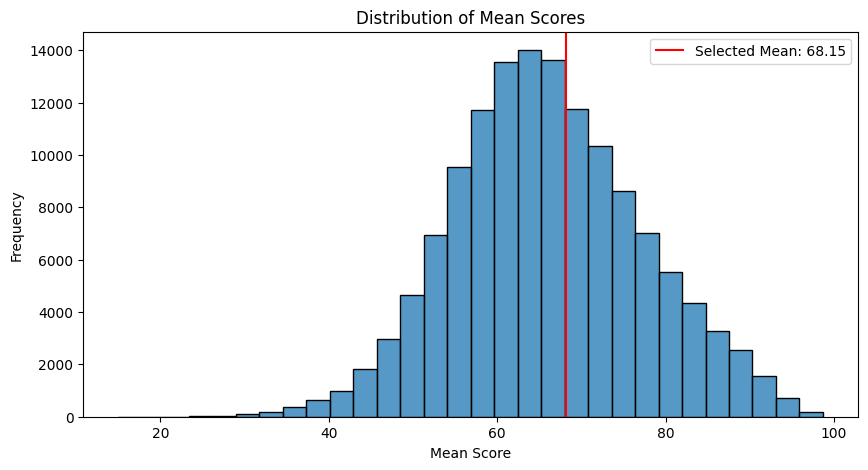

In [62]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['Mean Score'], bins=30)
plt.axvline(school_mean, color='red', label=f'Selected Mean: {round(school_mean,2)}')
plt.title('Distribution of Mean Scores')
plt.xlabel('Mean Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

This project analyzed Regents exams performance using Mean Scores as the selected feature. After cleaning the dataset and comparing Brooklyn Ascend Charter School to all Brooklyn schools, the results showed that the school performed above the borough average. Overall, the analysis suggests that the academic perfomance varies across schools, and Brooklyn Ascend Charter School stands out positively within Brooklyn.